# 📊 Exploratory Data Analysis - reviews.csv

## 1. Introducción

## Descripción del dataset
Este dataset contiene reseñas de listings.

### Campos:
- listing_id
- id
- date
- reviewer_id
- reviewer_name
- comments

### Objetivos
- Entender la estructura de los datos
- Detectar valores nulos o inconsistencias
- Analizar patrones en las reviews

## 2. Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

# Configuración visual
plt.style.use('default')
pd.set_option('display.max_columns', None)

## 3. Carga de datos

In [13]:
df = pd.read_csv('../data/reviews.csv')

df.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,96033,8152056,2013-10-18,366364,Vera,My stay at the apartment of Adriana and Rafa w...
1,96033,8689156,2013-11-12,4862098,Sarah,The flat was perfect for our holiday in Malaga...
2,96033,11862773,2014-04-17,2236416,Galina,El piso esta muy lindo y comido :) No había in...
3,96033,12689717,2014-05-08,13440727,Patricia,We had some trouble finding the appartment at ...
4,96033,13524708,2014-05-29,15892104,Monica,We were happy to meet so generous and availabl...


## 4. Exploración inicial

In [14]:
df.shape

(487221, 6)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 487221 entries, 0 to 487220
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   listing_id     487221 non-null  int64
 1   id             487221 non-null  int64
 2   date           487221 non-null  str  
 3   reviewer_id    487221 non-null  int64
 4   reviewer_name  487220 non-null  str  
 5   comments       487201 non-null  str  
dtypes: int64(3), str(3)
memory usage: 22.3 MB


In [16]:
df.describe(include='all')

,listing_id,id,date,reviewer_id,reviewer_name,comments
count,4.872210e+05,4.872210e+05,487221,4.872210e+05,487220,487201
unique,NaN,NaN,4518,NaN,61782,470280
top,NaN,NaN,2025-08-24,NaN,David,.
freq,NaN,NaN,677,NaN,3362,1258
mean,2.932385e+17,8.293236e+17,NaN,2.091664e+08,NaN,NaN
std,4.460335e+17,5.197223e+17,NaN,1.883583e+08,NaN,NaN
min,9.603300e+04,4.756450e+05,NaN,1.400000e+01,NaN,NaN
25%,1.922445e+07,4.671146e+17,NaN,4.879400e+07,NaN,NaN
50%,3.774592e+07,9.563531e+17,NaN,1.444575e+08,NaN,NaN
75%,6.744902e+17,1.261456e+18,NaN,3.531309e+08,NaN,NaN


## 5. Valores nulos

In [17]:
df.isnull().sum()

listing_id        0
id                0
date              0
reviewer_id       0
reviewer_name     1
comments         20
dtype: int64

In [28]:
reviewer_id_null =df[df["reviewer_name"].isnull()]["reviewer_id"]
df[df["reviewer_id"].isin(reviewer_id_null)]

,listing_id,id,date,reviewer_id,reviewer_name,comments
447496,1105154534760730240,1257842946402091988,2024-10-01,5310031,NaN,Alberto and Patricia’s place was a real find! ...


Solo tenemos una reseña de la persona con el `review_name` como faltante. Por lo que no podemos recuperar su nombre.

## 6. Duplicados

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df = df.drop_duplicates()

## 7. Análisis temporal

In [29]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

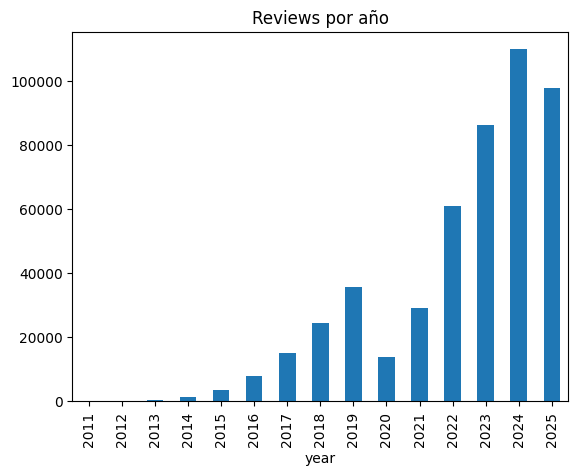

In [30]:
df['year'].value_counts().sort_index().plot(kind='bar')
plt.title("Reviews por año")
plt.show()

## 8. Análisis de reviewers

In [31]:
df['reviewer_id'].nunique()

448854

In [32]:
df['reviewer_name'].value_counts().head(10)

reviewer_name
David      3362
Laura      3217
Daniel     2562
Maria      2392
Anna       2088
Andrea     1927
Sarah      1904
Ana        1880
Michael    1856
Sara       1585
Name: count, dtype: int64

## 9. Análisis por listing

In [33]:
df['listing_id'].nunique()

8709

In [34]:
df['listing_id'].value_counts().head(10)

listing_id
30141259    1110
2343063      900
2336145      819
35637047     804
13315721     757
23220497     727
3051444      724
7541925      702
6225247      696
44574791     694
Name: count, dtype: int64

## 10. Análisis de texto

In [35]:
df['comments'].astype(str).str.len().describe()

count    487201.000000
mean        234.442370
std         218.728548
min           1.000000
25%          85.000000
50%         173.000000
75%         313.000000
max        5760.000000
Name: comments, dtype: float64

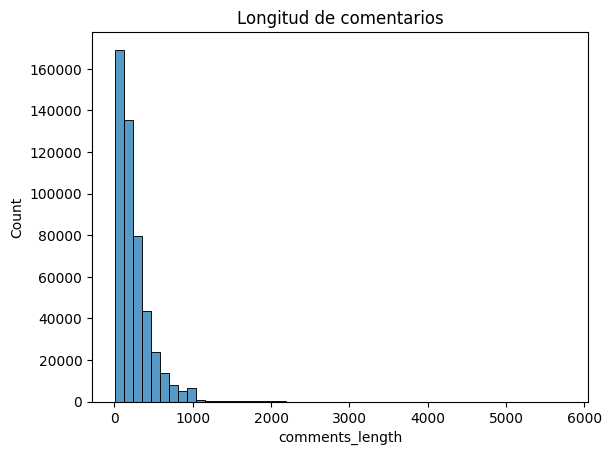

In [37]:
df['comments_length'] = df['comments'].str.len()

sns.histplot(df['comments_length'], bins=50)
plt.title("Longitud de comentarios")
plt.show()

## 11. Palabras más frecuentes

In [ ]:
text = " ".join(df['comments'].dropna().astype(str))
words = text.split()

Counter(words).most_common(10)

[('and', 481152),
 ('the', 475341),
 ('a', 376363),
 ('to', 288472),
 ('was', 255799),
 ('in', 237839),
 ('is', 218263),
 ('de', 206127),
 ('y', 170614),
 ('very', 142584)]

## 12. Limpieza básica

In [39]:
df['comments'] = df['comments'].astype(str).str.lower()

## 📌 Conclusiones

- Número total de reviews:
- Tendencia temporal:
- Usuarios más activos:
- Listings más comentados:
- Observaciones sobre los comentarios: